In [2]:
from dotenv import load_dotenv
# from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama

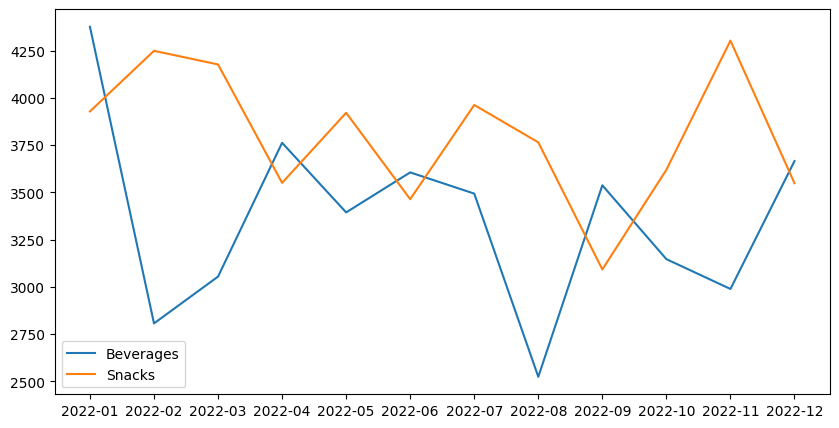

In [3]:
%run ./02_Trend_Anomaly_Detection.ipynb
%run ./03_Scenario_Simulation.ipynb

In [106]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [107]:
df= pd.read_csv('C:/Users/Prince_Jaiswal/Capstone1/data/cpg_sales_sample_5000.csv')

In [108]:
simulate_price_change(df, target_categories=None, price_change_pct=-0.1)

{'baseline_revenue': np.float64(337969.46),
 'projected_revenue': np.float64(317842.46),
 'revenue_change_pct': np.float64(-5.96),
 'elasticity_coefficient_used': 0.5}

In [109]:
def invoke_llm(prompt: str, model: str = "gpt-oss", temperature: float = 0.0) -> str:
    """
    Centralized utility to handle LLM calls with standardized error handling.
    """
    try:
        llm = ChatOllama(model=model, temperature=temperature)
        response = llm.invoke(prompt)
        return response.content.strip()
    except Exception as e:
        print(f"[LLM Error]: {e}")
        # Return a clean fallback message instead of crashing the notebook loop
        return (
            "LLM service unavailable (API timeout, quota exceeded, or billing issue).\n"
            "Please check your local Ollama connection or platform configurations."
        )

In [110]:
class Memory:
    def __init__(self):
        self.history = []

    def add(self, role, message):
        self.history.append({"role": role, "content": message})

    def get(self):
        return "\n".join(
            [f"{h['role']}: {h['content']}" for h in self.history]
        )

In [111]:
class CPGDecisionAgent:
    def __init__(self):
        self.df = df
        self.memory = Memory()

        # # LLM initialization (used only when needed)
        # self.llm = ChatOpenAI(
        #     model="gpt-4o-mini",
        #     temperature=0.3
        # )
        self.llm = ChatOllama(
            model="gpt-oss",
            temperature=0.0
        )

    # -----------------------------
    # Main Agent Execution
    # -----------------------------
    def run(self, query: str):

        detect_intent_prompt = f"""
        You are an intelligent intent detection and parameter extraction assistant for a CPG analytics platform. 
        Analyze the user's query, select the correct tool ("trend_analysis", "anomaly_detection", "price_change_simulation", "promo_campaign_simulation", "strategy_memo" and "other"), and extract parameters.

        Output Format (Strict JSON only, no markdown wrappers):
        {{
            "tool": "tool_name",
            "parameters": {{
                "target_regions": ["Region1", "Region2"] or null,
                "target_categories": ["Category1"] or null,
                "anomaly_col": target column for anomaly detection query or null (if not provided),
                "price_change_pct": float or null,
                "elasticity_coefficient": elasticity coefficent for price change simulation or null (if not provided),
                "promo_type"= "FlashSale" or "Discount" or "BuyOneGetOne" or null (if not provided),
                "discount_pct"= For promo campaign simulation query or null (if not provided),
                "conversion_rate" = For promo campaign simulation query or null (if not provided),
                "lift_factor" = For promo campaign simulation query or null (if not provided)
            }}
        }}

        Business query: {query}
        Output:
        """
        
        # Get response from LLM
        response = self.llm.invoke(detect_intent_prompt).content.strip()

        print("llm response for detect_intent_prompt: ", response)
        
        try:
            intent_data = json.loads(response)
            tool = intent_data.get("tool")
            params = intent_data.get("parameters", {})
        except Exception as e:
            # Fallback to safe defaults if JSON parsing fails
            print(f"Failed to parse LLM response: {e}")
            return {"type": "other", "text": "Sorry, I couldn't process that query structurally."}

        # ---------------- DYNAMIC TOOL ROUTING ----------------
        if tool == "trend_analysis":
            # Pass extracted parameters dynamically instead of hardcoding
            regions = params.get("target_regions")
            categories = params.get("target_categories")
            
            monthly, summary = analyze_trends(self.df, target_regions=regions, target_categories=categories)
            return {"type": "trend_analysis", "monthly": monthly, "summary": summary}
            
        elif tool == "anomaly_detection":
            col = params.get("anomaly_col") if params.get("anomaly_col") is not None else "units_sold"
            regions = params.get("target_regions")
            categories = params.get("target_categories")
            
            summary = detect_anomalies(self.df, target_col=col, target_regions=regions, target_categories=categories)
            return {"type": "anomaly_detection", "summary": summary}
            
        elif tool == "price_change_simulation":
            # Handle default percentage if not extracted, or let function handle it
            pct = params.get("price_change_pct") if params.get("price_change_pct") is not None else 0.15
            categories = params.get("target_categories")
            
            impact = simulate_price_change(self.df, target_categories=categories, price_change_pct=pct)
            return {"type": "price_change_simulation", "impact": impact}

        elif tool == "promo_campaign_simulation":
            # Handle default percentage if not extracted, or let function handle it
            discount_pct = params.get("discount_pct")  if params.get("discount_pct") is not None else 0.2
            categories = params.get("target_categories")
            promo_type = params.get("promo_type") if params.get("promo_type") is not None else "FlashSale"
            conversion_rate = params.get("conversion_rate") if params.get("conversion_rate") is not None else 0.3
            lift_factor = params.get("lift_factor") if params.get("lift_factor") is not None else 1.5           

            impact = simulate_promo_campaign(self.df, target_categories=categories, discount_pct=discount_pct, promo_type=promo_type, conversion_rate=conversion_rate, lift_factor=lift_factor)
            return {"type": "promo_campaign_simulation", "impact": impact}

        elif tool == "strategy_memo":
            memory_text = self.memory.get()

            prompt = f"""
                You are a Senior CPG Strategy Consultant.
                
                Business Question:
                {query}
                
                Previous Conversation:
                {memory_text}
                
                Generate:
                1. Key Insight
                2. Business Impact
                3. Recommendation
                
                Keep it executive-level and concise.
                """

            print("memory_text: ", memory_text)
            answer = self.invoke_llm(prompt).content.strip()

            # Save to memory and return
            self.memory.add("User", query)
            self.memory.add("Assistant", answer)
            return {
                "type": "strategy_memo", 
                "text": answer
            }
        else:
            return {
                "type": "other",
                "text": "Unable to detect intent or the intent not related to CPG business query."
            }

In [112]:
def generate_final_response(result) -> str:
    """
    Generates a brief summary in human-readable sentences based on tool results.
    """
    print("generate_final_response input: ", result)
    
    prompt = f"""
    Generate a brief summary in human-readable sentences based on the tool results:
    Result: {result}
    """
    return invoke_llm(prompt)

In [113]:
def main():
    
    agent = CPGDecisionAgent()
    
    while True:
        query = input("Ask a business question (or type 'exit'): ")
        if not query or query.lower() == 'exit':
            break
            
        # Run the agent to detect intent and execute the tool
        result = agent.run(query)
        response_text = ""
    
        # ---------------- TREND ANALYSIS ----------------
        if result["type"] == "trend_analysis":
    
            summary = result["summary"]
            print("summary: ", summary)
    
            monthly = result["monthly"]
    
            chart_data = monthly.pivot(
                index="month",
                columns="category",
                values="revenue"
            )
    
            plt.figure(figsize=(10, 5))
            plt.plot(chart_data, label=chart_data.columns)
            plt.legend()
            plt.show()

            response_text = generate_final_response(summary)
            print("Final Response: ", response_text)
    
        # ---------------- ANOMALY DETECTION ----------------
        elif result["type"] == "anomaly_detection":
            summary = result["summary"]
            response_text = generate_final_response(summary)
            print("Final Response: ", response_text)

        # ---------------- PRICE CHANGE SIMULATION ----------------
        elif result["type"] == "price_change_simulation":
            impact = result["impact"]
            response_text = generate_final_response(impact)
            print("Final Response: ", response_text)

        # ---------------- PROMO CAMPAIGN SIMULATION ----------------
        elif result["type"] == "promo_campaign_simulation":
            impact = result["impact"]
            response_text = generate_final_response(impact)
            print("Final Response: ", response_text)

        # ---------------- STRATEGY MEMO GENERATION ----------------
        elif result["type"] == "strategy_memo":
            response_text = result["text"]
            print("Final Response: ", response_text)

        # ---------------- OTHERS / FALLBACK ----------------
        else:
            response_text = result["text"]
            print("Final Response: ", response_text)
            
        # Append the full turn to memory so the next 'strategy_memo' call can read it!
        if result["type"] != "strategy_memo":
            agent.memory.add("User", query)
            agent.memory.add("Assistant", response_text)

In [114]:
if __name__ == "__main__":
    main()

Ask a business question (or type 'exit'):  Can you simulate a new promo campaign 'FlashSale' with discount of 15% for all regions, with a conversion rate of 35%.


llm response for detect_intent_prompt:  {"tool":"promo_campaign_simulation","parameters":{"target_regions":null,"target_categories":null,"anomaly_col":null,"price_change_pct":null,"elasticity_coefficient":null,"promo_type":"FlashSale","discount_pct":0.15,"conversion_rate":0.35,"lift_factor":null}}
generate_final_response input:  {'baseline_revenue': np.float64(337969.46), 'projected_revenue': np.float64(376427.98), 'revenue_change_pct': np.float64(11.38), 'discount_pct_used': 0.15, 'conversion_rate_used': 0.35, 'lift_factor_used': 1.5}
Final Response:  The analysis shows that the baseline revenue was **$337,969.46**. With the applied discount of **15 %**, a conversion rate of **35 %**, and a lift factor of **1.5**, the projected revenue rises to **$376,427.98**. This represents an **11.38 % increase** over the baseline.


Ask a business question (or type 'exit'):  can you generate a strategy memo based on the last promo campaign query


llm response for detect_intent_prompt:  {"tool":"strategy_memo","parameters":{"target_regions":null,"target_categories":null,"anomaly_col":null,"price_change_pct":null,"elasticity_coefficient":null,"promo_type":null,"discount_pct":null,"conversion_rate":null,"lift_factor":null}}
Final Response:  **Strategy Memo – FlashSale Promo Campaign**

| Item | Detail |
|------|--------|
| **Baseline Revenue** | $337,969.46 |
| **Projected Revenue (15 % discount, 35 % conversion, 1.5 lift)** | $376,427.98 |
| **Revenue Lift** | **+11.38 %** |

---

### 1. Key Insight  
The FlashSale promotion delivers a **significant 11.4 % lift in revenue** while applying a modest 15 % discount across all regions. The high conversion rate (35 %) combined with a 1.5× lift factor indicates strong consumer responsiveness to time‑limited price reductions.

### 2. Business Impact  
- **Revenue Growth**: $38,458.52 incremental revenue, translating to a 11.4 % increase over baseline.  
- **Margin Considerations**: A 15 

Ask a business question (or type 'exit'):  exit


In [102]:
simulate_promo_campaign(df, discount_pct=0.15, conversion_rate=0.35)

{'baseline_revenue': np.float64(337969.46),
 'projected_revenue': np.float64(376427.98),
 'revenue_change_pct': np.float64(11.38),
 'discount_pct_used': 0.15,
 'conversion_rate_used': 0.35,
 'lift_factor_used': 1.5}

In [7]:
# show trend in the cpg data
# show trend in the cpg data of North and East store regions
monthly, summary = analyze_trends(df, target_regions=['North', 'East'], target_categories=['Snacks', 'Beverages'],)
summary

{'total_revenue': np.float64(85948.32),
 'total_units': 15406,
 'top_category': 'Snacks'}

In [8]:
# can you share if there are any anomalies in cpg data
# can you share if there are any anomalies in the Dairy and Snacks categories
detect_anomalies(df, target_categories=['Snacks', 'Dairy'])

{'lower_bound': np.float64(-9.0),
 'upper_bound': np.float64(39.0),
 'total anomalies found': 48,
 'top 5 anomalies below the lower bound': Empty DataFrame
 Columns: []
 Index: [],
 'top 5 anomalies above the upper bound':          date  store_id  units_sold
 0  2022-07-28         2          61
 1  2022-03-09         4          59
 2  2022-09-03         2          58
 3  2022-10-26         6          57
 4  2022-05-28         7          55}

In [10]:
# can you help me with the revenue impact if we change the price by 20%
simulate_price_change(df, price_change_pct=0.2)

{'baseline_revenue': np.float64(337969.46),
 'projected_revenue': np.float64(364515.7),
 'revenue_change_pct': np.float64(7.85),
 'elasticity_coefficient_used': 0.5}

In [9]:
# Can you simulate a new promo campaign 'FlashSale' with discount of 15% for all regions, with a conversion rate of 35%.
simulate_promo_campaign(df, discount_pct=0.15, conversion_rate=0.35)

{'baseline_revenue': np.float64(337969.46),
 'projected_revenue': np.float64(376427.98),
 'revenue_change_pct': np.float64(11.38),
 'discount_pct_used': 0.15,
 'conversion_rate_used': 0.35,
 'lift_factor_used': 1.5}

In [ ]:
# can you generate a strategy memo based on the last promo campaign query